In [ ]:
# Data Loading and Initial Preview
import pandas as pd
import numpy as np

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (10443, 7)


,experience,country,education,languages,frameworks,company_size,salary_usd
0,34.0,Germany,Masters,"Rust, JavaScript","Vue, ASP.NET",201-1000,172292
1,9.0,UK,Masters,"C#, JavaScript","Ruby on Rails, Spring",201-1000,82311
2,8.0,USA,Some College,"C++, Go","Vue, React",5000+,109637
3,29.0,USA,Masters,"C++, Ruby","Spring, Angular",Nov-50,214386
4,7.0,USA,Bachelors,"C#, Rust","React, Express",10-Jan,107584


In [9]:
DATA_PATH = 'https://raw.githubusercontent.com/abir945/AI_ML_LAB/main/SVM/dataset/train.csv'

In [10]:
# Basic Data Exploration
print("Column names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Column names:
['experience', 'country', 'education', 'languages', 'frameworks', 'company_size', 'salary_usd']

Data types:
experience      float64
country          object
education        object
languages        object
frameworks       object
company_size     object
salary_usd        int64
dtype: object

Missing values:
experience      1
country         0
education       0
languages       0
frameworks      0
company_size    0
salary_usd      0
dtype: int64

Duplicate rows: 0


In [ ]:
# Statistical Summary of Features
display(df.describe(include='all').T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
experience,10442.0,NaN,NaN,NaN,19.878472,11.815038,0.0,10.0,20.0,30.0,40.0
country,10443,10,USA,4102,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education,10443,5,Bachelors,5242,NaN,NaN,NaN,NaN,NaN,NaN,NaN
languages,10443,100,"PHP, PHP",139,NaN,NaN,NaN,NaN,NaN,NaN,NaN
frameworks,10443,100,"Laravel, Vue",133,NaN,NaN,NaN,NaN,NaN,NaN,NaN
company_size,10443,6,51-200,1773,NaN,NaN,NaN,NaN,NaN,NaN,NaN
salary_usd,10443.0,NaN,NaN,NaN,131736.778129,46195.765324,12064.0,98291.5,131291.0,164217.5,273362.0
salary_class,10443.0,NaN,NaN,NaN,0.500048,0.500024,0.0,0.0,1.0,1.0,1.0


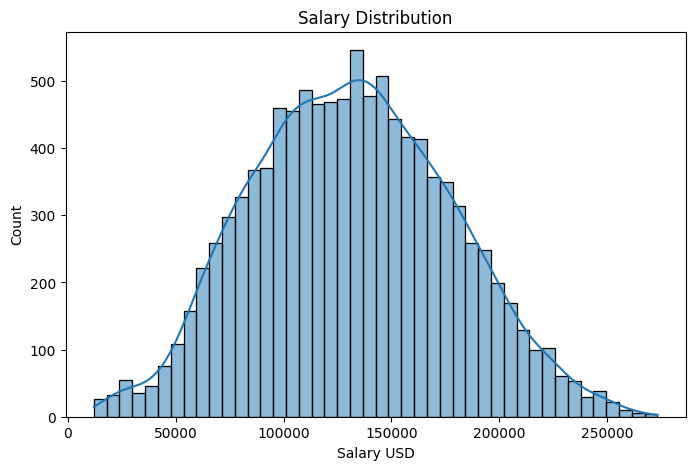

In [11]:
#Salary Distribution
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

plt.figure(figsize=(8, 5))
sns.histplot(df['salary_usd'], kde=True)
plt.title('Salary Distribution')
plt.xlabel('Salary USD')
plt.ylabel('Count')
plt.show()

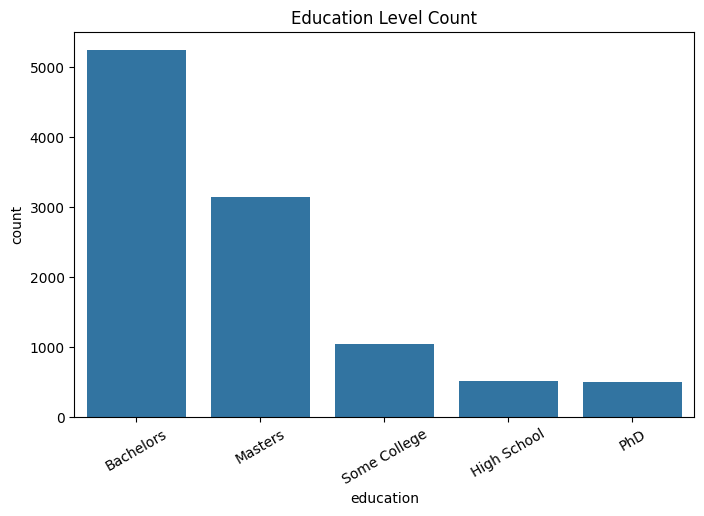

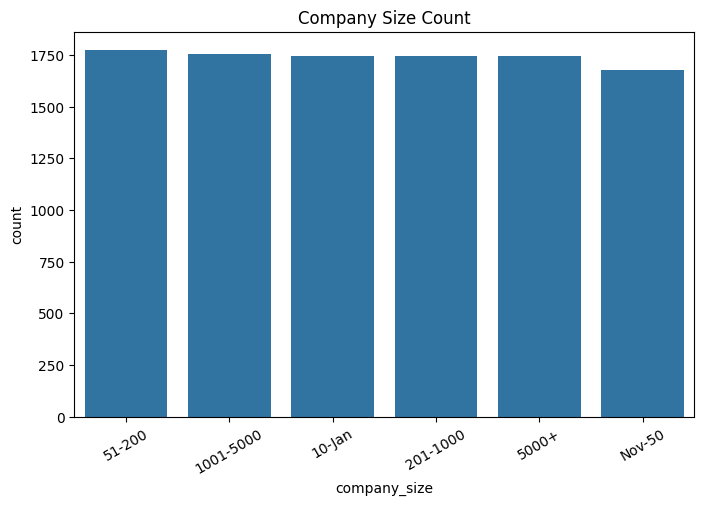

In [ ]:
# Categorical Feature Distribution
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='education', order=df['education'].value_counts().index)
plt.title('Education Level Count')
plt.xticks(rotation=30)
plt.show()

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='company_size', order=df['company_size'].value_counts().index)
plt.title('Company Size Count')
plt.xticks(rotation=30)
plt.show()

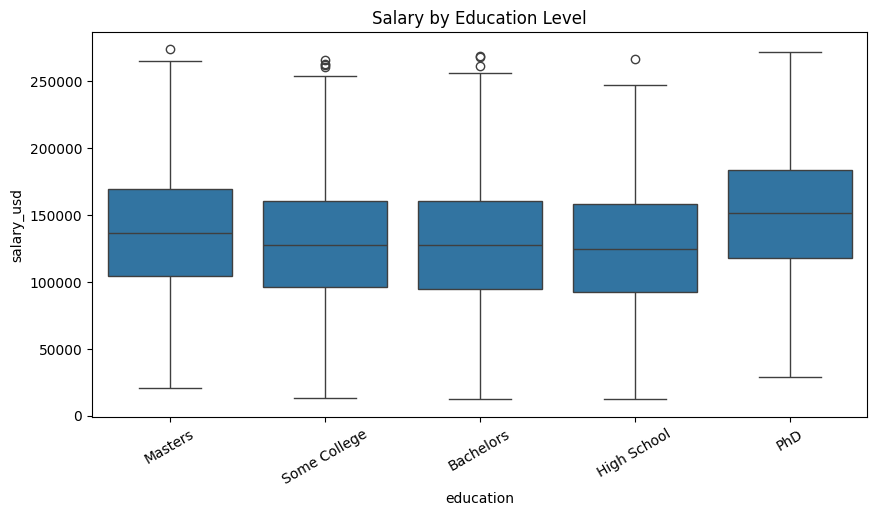

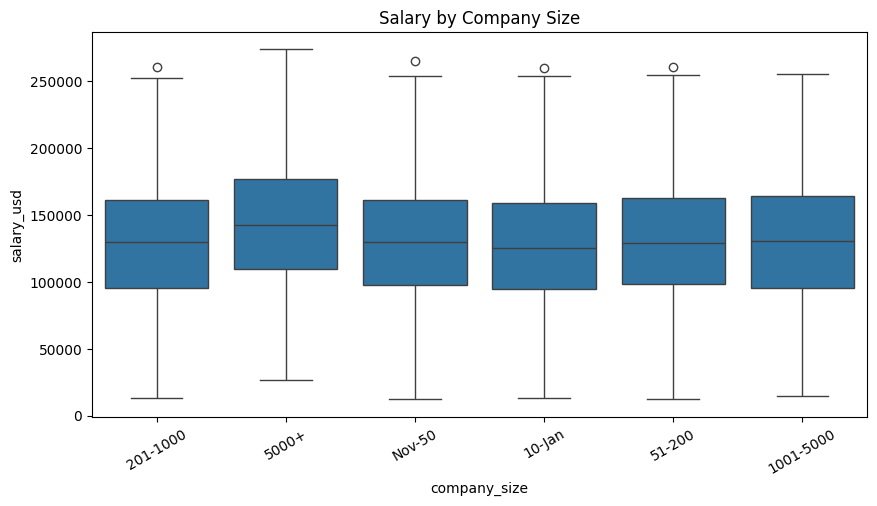

In [ ]:
# Bivariate Analysis: Salary vs Categorical Features
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='education', y='salary_usd')
plt.title('Salary by Education Level')
plt.xticks(rotation=30)
plt.show()

plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='company_size', y='salary_usd')
plt.title('Salary by Company Size')
plt.xticks(rotation=30)
plt.show()

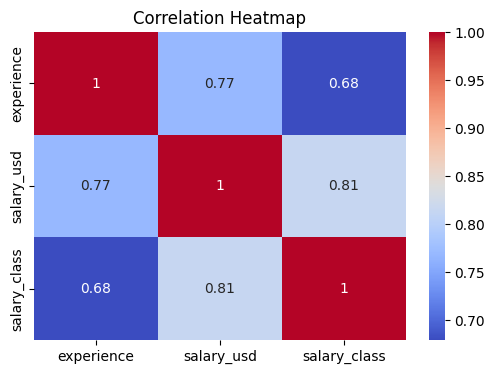

In [ ]:
# Feature Correlation Analysis
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(6, 4))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [ ]:
# Target Discretization (Salary Classification)
median_salary = df['salary_usd'].median()
print("Median salary:", median_salary)

df['salary_class'] = np.where(df['salary_usd'] >= median_salary, 1, 0)

print("\nTarget distribution:")
print(df['salary_class'].value_counts())
print("\nTarget distribution percentage:")
print(df['salary_class'].value_counts(normalize=True) * 100)

Median salary: 131291.0

Target distribution:
salary_class
1    5222
0    5221
Name: count, dtype: int64

Target distribution percentage:
salary_class
1    50.004788
0    49.995212
Name: proportion, dtype: float64


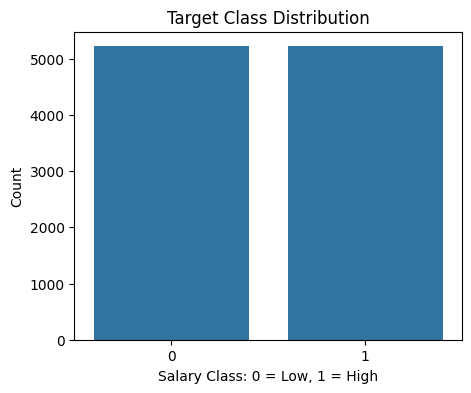

In [ ]:
# Target Class Distribution Visualization
plt.figure(figsize=(5, 4))
sns.countplot(data=df, x='salary_class')
plt.title('Target Class Distribution')
plt.xlabel('Salary Class: 0 = Low, 1 = High')
plt.ylabel('Count')
plt.show()



In [ ]:
# Feature and Target Selection
X = df.drop(columns=['salary_usd', 'salary_class'])
y = df['salary_class']

print("Feature columns:")
print(X.columns.tolist())

print("\nTarget column:")
print('salary_class')

Feature columns:
['experience', 'country', 'education', 'languages', 'frameworks', 'company_size']

Target column:
salary_class


In [ ]:
# Data Splitting (Train/Val/Test)
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Test set:", X_test.shape)

Training set: (7310, 6)
Validation set: (1566, 6)
Test set: (1567, 6)


In [ ]:
# Preprocessing Pipelines for Numeric and Categorical Data
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

In [ ]:
# Baseline SVM Model Training and Validation
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

baseline_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42))
])

baseline_model.fit(X_train, y_train)

val_pred = baseline_model.predict(X_val)
val_prob = baseline_model.predict_proba(X_val)[:, 1]

print("Baseline Validation Accuracy:", accuracy_score(y_val, val_pred))
print("Baseline Validation Precision:", precision_score(y_val, val_pred))
print("Baseline Validation Recall:", recall_score(y_val, val_pred))
print("Baseline Validation F1-score:", f1_score(y_val, val_pred))
print("Baseline Validation AUC:", roc_auc_score(y_val, val_prob))

Baseline Validation Accuracy: 0.8812260536398467
Baseline Validation Precision: 0.8812260536398467
Baseline Validation Recall: 0.8812260536398467
Baseline Validation F1-score: 0.8812260536398467
Baseline Validation AUC: 0.9633707341022266


In [ ]:
# Hyperparameter Tuning using RandomizedSearchCV
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

svm_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', SVC(probability=True, random_state=42))
])

param_distributions = {
    'classifier__kernel': ['linear', 'rbf', 'poly'],
    'classifier__C': [0.1, 1, 10, 100],
    'classifier__gamma': ['scale', 'auto', 0.01, 0.1, 1],
    'classifier__degree': [2, 3, 4]
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(
    estimator=svm_pipeline,
    param_distributions=param_distributions,
    n_iter=20,
    scoring='f1',
    cv=cv,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train, y_train)

print("Best parameters:", random_search.best_params_)
print("Best cross-validation F1-score:", random_search.best_score_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best parameters: {'classifier__kernel': 'linear', 'classifier__gamma': 1, 'classifier__degree': 4, 'classifier__C': 0.1}
Best cross-validation F1-score: 0.8900469112397293


In [ ]:
# Best Model Validation Results
best_model = random_search.best_estimator_

val_pred = best_model.predict(X_val)
val_prob = best_model.predict_proba(X_val)[:, 1]

print("Validation Accuracy:", accuracy_score(y_val, val_pred))
print("Validation Precision:", precision_score(y_val, val_pred))
print("Validation Recall:", recall_score(y_val, val_pred))
print("Validation F1-score:", f1_score(y_val, val_pred))
print("Validation AUC:", roc_auc_score(y_val, val_prob))

Validation Accuracy: 0.8844189016602809
Validation Precision: 0.8878865979381443
Validation Recall: 0.879948914431673
Validation F1-score: 0.8838999358563181
Validation AUC: 0.9653443464162625


In [ ]:
# Final Model Evaluation on Test Set
from sklearn.metrics import classification_report, confusion_matrix

test_pred = best_model.predict(X_test)
test_prob = best_model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, test_pred)
precision = precision_score(y_test, test_pred)
recall = recall_score(y_test, test_pred)
f1 = f1_score(y_test, test_pred)
auc = roc_auc_score(y_test, test_prob)

print("Final Test Evaluation Metrics")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)
print("AUC      :", auc)

print("\nClassification Report:")
print(classification_report(y_test, test_pred, target_names=['Low Salary', 'High Salary']))

Final Test Evaluation Metrics
Accuracy : 0.8698149329929802
Precision: 0.8776041666666666
Recall   : 0.8596938775510204
F1-score : 0.8685567010309279
AUC      : 0.9595094742877994

Classification Report:
              precision    recall  f1-score   support

  Low Salary       0.86      0.88      0.87       783
 High Salary       0.88      0.86      0.87       784

    accuracy                           0.87      1567
   macro avg       0.87      0.87      0.87      1567
weighted avg       0.87      0.87      0.87      1567



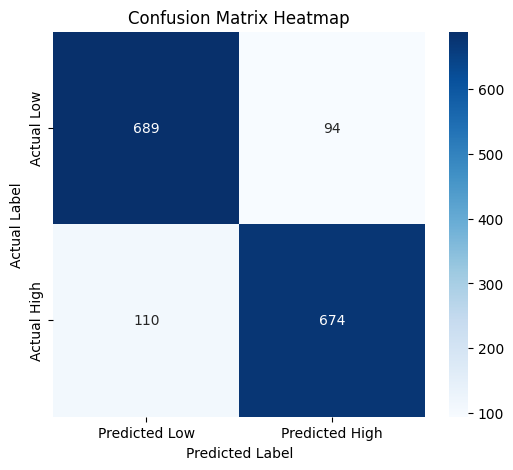

In [ ]:
# Confusion Matrix Visualization
cm = confusion_matrix(y_test, test_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Low', 'Predicted High'],
            yticklabels=['Actual Low', 'Actual High'])
plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

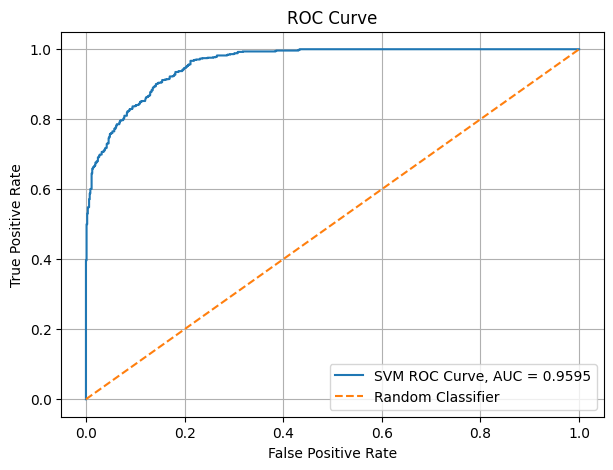

In [ ]:
# ROC Curve and AUC Visualization
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, test_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f'SVM ROC Curve, AUC = {auc:.4f}')
plt.plot([0, 1], [0, 1], linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Sample Prediction Results Display
sample_results = X_test.copy()
sample_results['Actual'] = y_test.values
sample_results['Predicted'] = test_pred
sample_results['Probability_High_Salary'] = test_prob

sample_results['Actual_Label'] = sample_results['Actual'].map({0: 'Low Salary', 1: 'High Salary'})
sample_results['Predicted_Label'] = sample_results['Predicted'].map({0: 'Low Salary', 1: 'High Salary'})

display(sample_results[['Actual_Label', 'Predicted_Label', 'Probability_High_Salary']].head(20))


,Actual_Label,Predicted_Label,Probability_High_Salary
1363,Low Salary,Low Salary,0.431792
5441,Low Salary,Low Salary,0.000340
5202,High Salary,High Salary,0.975744
7143,High Salary,High Salary,0.984385
75,Low Salary,Low Salary,0.023314
3942,High Salary,Low Salary,0.415654
1510,High Salary,High Salary,1.000000
10232,Low Salary,Low Salary,0.056932
3762,Low Salary,Low Salary,0.000603
3392,Low Salary,Low Salary,0.354623


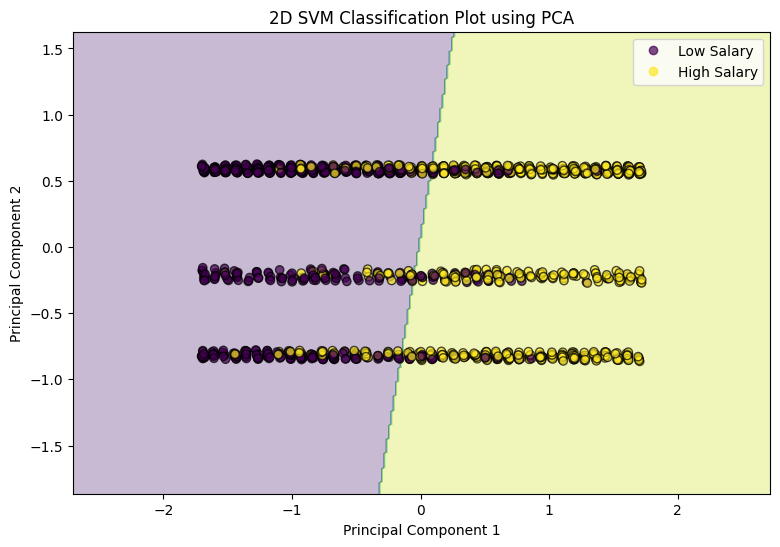

In [ ]:
# 2D SVM Classification Visualization using PCA
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline

# Preprocess data separately
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Convert sparse matrix to dense if needed
if hasattr(X_train_processed, "toarray"):
    X_train_processed_dense = X_train_processed.toarray()
    X_test_processed_dense = X_test_processed.toarray()
else:
    X_train_processed_dense = X_train_processed
    X_test_processed_dense = X_test_processed

pca = PCA(n_components=2, random_state=42)
X_train_2d = pca.fit_transform(X_train_processed_dense)
X_test_2d = pca.transform(X_test_processed_dense)

svm_2d = SVC(
    kernel=random_search.best_params_['classifier__kernel'],
    C=random_search.best_params_['classifier__C'],
    gamma=random_search.best_params_['classifier__gamma'],
    degree=random_search.best_params_['classifier__degree'],
    probability=True,
    random_state=42
)

svm_2d.fit(X_train_2d, y_train)

# Create mesh grid
x_min, x_max = X_test_2d[:, 0].min() - 1, X_test_2d[:, 0].max() + 1
y_min, y_max = X_test_2d[:, 1].min() - 1, X_test_2d[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

Z = svm_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(9, 6))
plt.contourf(xx, yy, Z, alpha=0.3)
scatter = plt.scatter(X_test_2d[:, 0], X_test_2d[:, 1], c=y_test, edgecolor='k', alpha=0.7)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('2D SVM Classification Plot using PCA')
plt.legend(handles=scatter.legend_elements()[0], labels=['Low Salary', 'High Salary'])
plt.show()


In [ ]:
##This project implements a Support Vector Machine classifier using the Breast Cancer Wisconsin Diagnostic dataset. The dataset contains numerical features computed from digitized images of breast mass cell nuclei. The target variable is binary, representing malignant and benign classes.

##The workflow includes dataset loading, data exploration, missing value checking, feature preprocessing, train-validation-test splitting, SVM model training, hyperparameter tuning, and model evaluation. Missing values are handled using median imputation for numerical features. Numerical features are standardized using StandardScaler. A preprocessing pipeline is used to ensure that the same transformations are applied consistently during training and testing.

##For model optimization, GridSearchCV is used to tune kernel, C, gamma, and degree. The best model is selected based on ROC-AUC score. The final model is evaluated using accuracy, precision, recall, F1-score, AUC, confusion matrix, ROC curve, sample predictions, and a 2D classification boundary plot.

##The results show that SVM performs well on this binary classification problem after proper preprocessing and hyperparameter tuning.